In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np


X, y = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)


class SimpleNet(nn.Module):
    def __init__(self, activation_fn=nn.ReLU, input_size=2, hidden_size=64, output_size=1):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.activation1 = activation_fn()
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.activation2 = activation_fn()
        self.linear3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation1(x)
        x = self.linear2(x)
        x = self.activation2(x)
        x = self.linear3(x)
        return x










In [4]:

# Training function
def train_model(model, X_data, y_data, epochs=10000, lr=0.001):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    lossi = []

    for i in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_data)
        loss = criterion(outputs, y_data)
        loss.backward()
        optimizer.step()
        lossi.append(loss.item())
    return lossi


Running Zero Initialization Experiments...


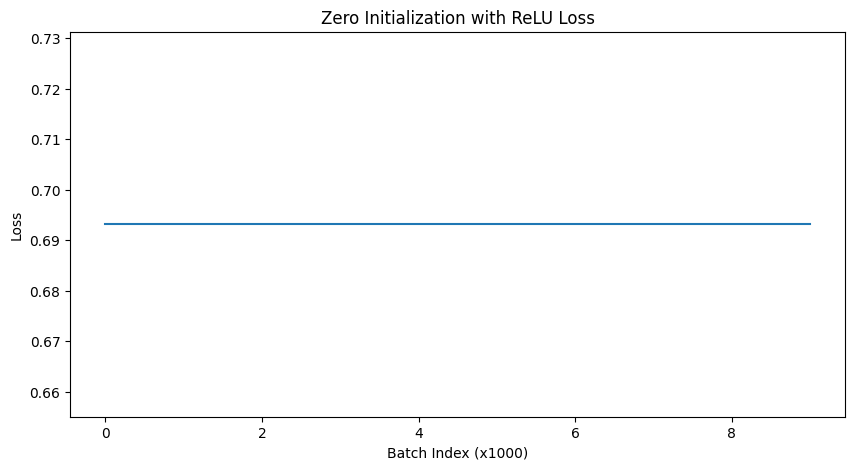

In [5]:
print("Running Zero Initialization Experiments...")

# Zero Initialization with ReLU
model_zero_relu = SimpleNet(activation_fn=nn.ReLU)
for p in model_zero_relu.parameters():
    p.data.zero_()
lossi_zero_relu = train_model(model_zero_relu, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_zero_relu).view(-1, 1000).mean(1))
plt.title('Zero Initialization with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()


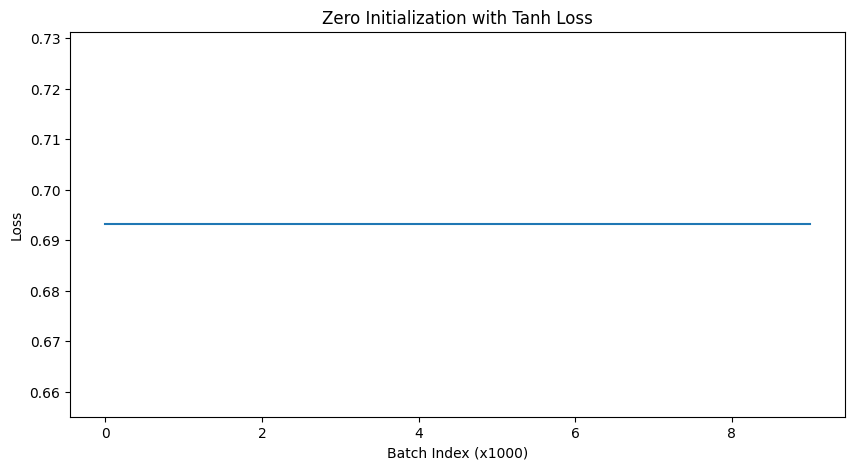

In [6]:
# Zero Initialization with Tanh
model_zero_tanh = SimpleNet(activation_fn=nn.Tanh)
for p in model_zero_tanh.parameters():
    p.data.zero_()
lossi_zero_tanh = train_model(model_zero_tanh, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_zero_tanh).view(-1, 1000).mean(1))
plt.title('Zero Initialization with Tanh Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()


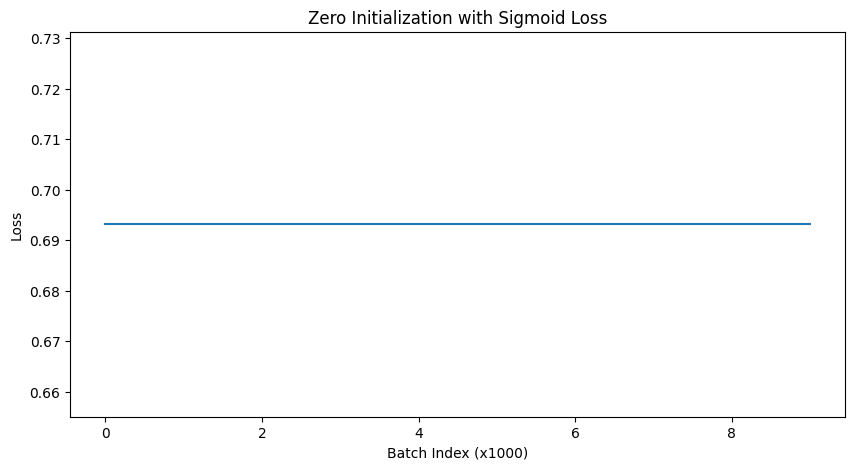

In [7]:
# Zero Initialization with Sigmoid
model_zero_sigmoid = SimpleNet(activation_fn=nn.Sigmoid)
for p in model_zero_sigmoid.parameters():
    p.data.zero_()
lossi_zero_sigmoid = train_model(model_zero_sigmoid, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_zero_sigmoid).view(-1, 1000).mean(1))
plt.title('Zero Initialization with Sigmoid Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

Running Random Initialization Experiments...


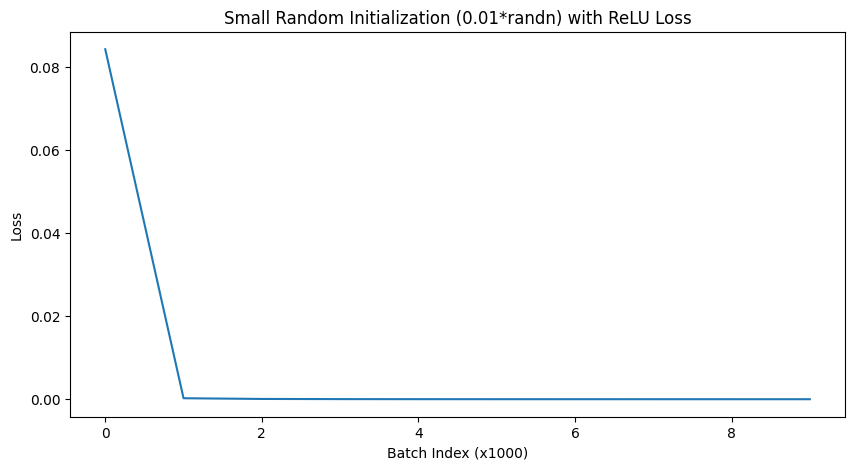

In [8]:
# Experiment 2: Random Initialization (with ReLU)
print("Running Random Initialization Experiments...")

# Small Random Initialization
model_small_rand = SimpleNet(activation_fn=nn.ReLU)
for p in model_small_rand.parameters():
    if p.dim() > 1:
        p.data.normal_(0, 0.01)
    else:
        p.data.zero_()
lossi_small_rand = train_model(model_small_rand, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_small_rand).view(-1, 1000).mean(1))
plt.title('Small Random Initialization (0.01*randn) with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

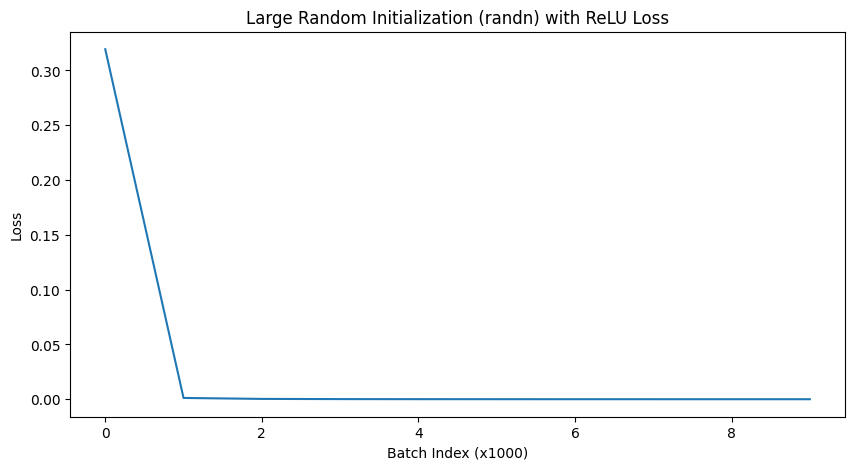

In [9]:
# Large Random Initialization
model_large_rand = SimpleNet(activation_fn=nn.ReLU)
for p in model_large_rand.parameters():
    if p.dim() > 1:
        p.data.normal_(0, 1)
    else:
        p.data.zero_()
lossi_large_rand = train_model(model_large_rand, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_large_rand).view(-1, 1000).mean(1))
plt.title('Large Random Initialization (randn) with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()


Running Xavier/Glorot Initialization Experiments...


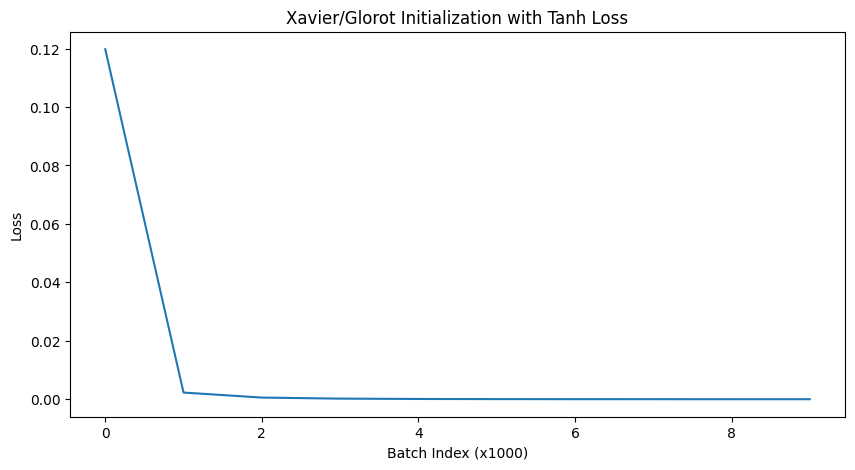

In [10]:
# Experiment 3: Xavier / Glorot Initialization (with Tanh/Sigmoid)
print("Running Xavier/Glorot Initialization Experiments...")

# Xavier/Glorot Initialization with Tanh
model_xavier_tanh = SimpleNet(activation_fn=nn.Tanh)
with torch.no_grad():
    for m in model_xavier_tanh.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            fan_out = m.weight.size(0)
            gain = 5/3  # For Tanh
            std = gain * (2 / (fan_in + fan_out))**0.5
            m.weight.normal_(0, std)
            if m.bias is not None:
                m.bias.zero_()
lossi_xavier_tanh = train_model(model_xavier_tanh, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_xavier_tanh).view(-1, 1000).mean(1))
plt.title('Xavier/Glorot Initialization with Tanh Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

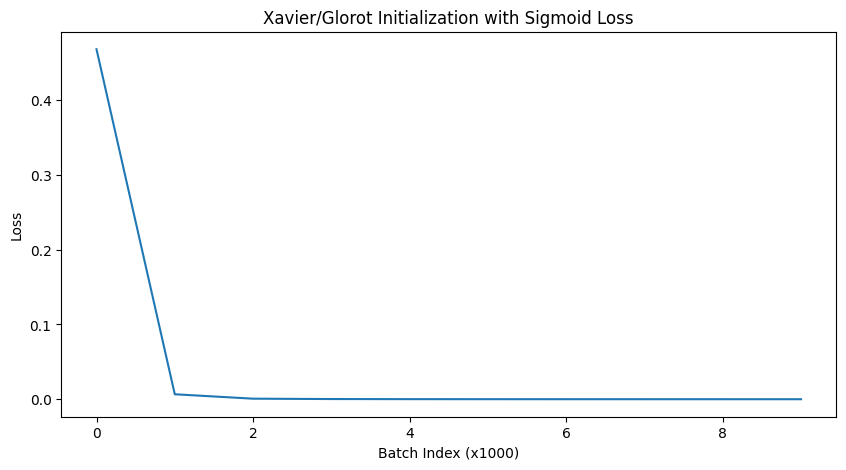

In [11]:

# Xavier/Glorot Initialization with Sigmoid
model_xavier_sigmoid = SimpleNet(activation_fn=nn.Sigmoid)
with torch.no_grad():
    for m in model_xavier_sigmoid.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            fan_out = m.weight.size(0)
            gain = 1.0  # For Sigmoid
            std = gain * (2 / (fan_in + fan_out))**0.5
            m.weight.normal_(0, std)
            if m.bias is not None:
                m.bias.zero_()
lossi_xavier_sigmoid = train_model(model_xavier_sigmoid, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_xavier_sigmoid).view(-1, 1000).mean(1))
plt.title('Xavier/Glorot Initialization with Sigmoid Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

Running He Initialization Experiments...


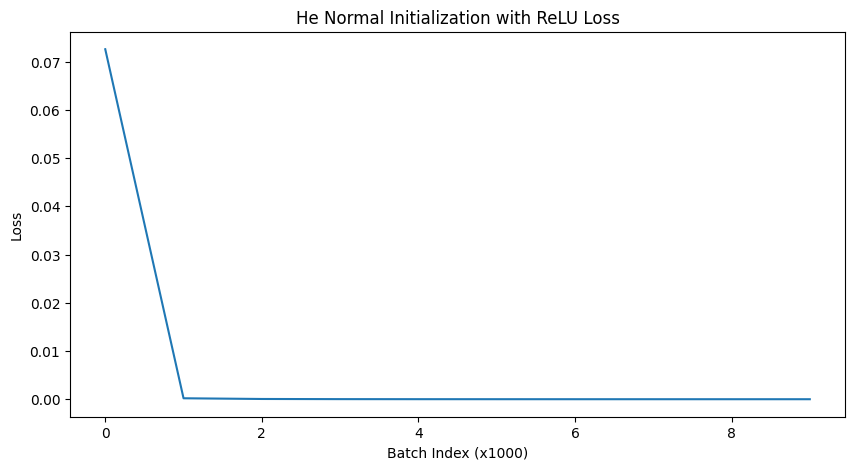

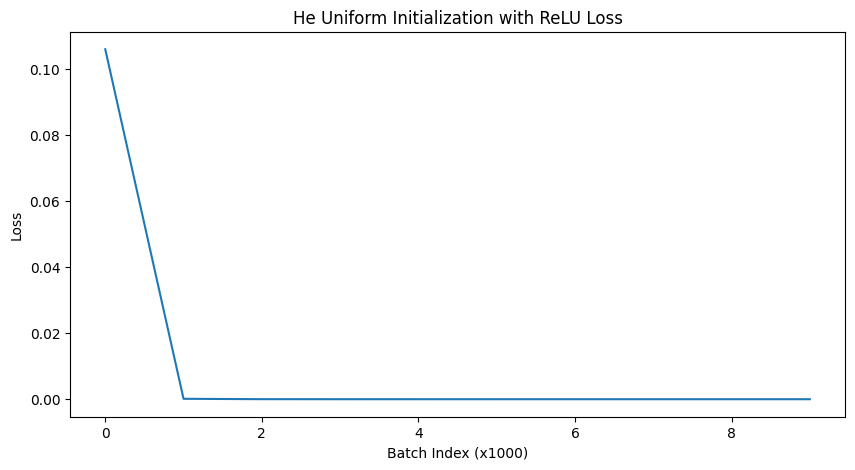

In [12]:




# Experiment 4: He Initialization (with ReLU)
print("Running He Initialization Experiments...")

# He Normal Initialization
model_he_normal = SimpleNet(activation_fn=nn.ReLU)
with torch.no_grad():
    for m in model_he_normal.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            gain = np.sqrt(2.0)  # For ReLU
            std = gain * (1 / fan_in)**0.5
            m.weight.normal_(0, std)
            if m.bias is not None:
                m.bias.zero_()
lossi_he_normal = train_model(model_he_normal, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_he_normal).view(-1, 1000).mean(1))
plt.title('He Normal Initialization with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

# He Uniform Initialization
model_he_uniform = SimpleNet(activation_fn=nn.ReLU)
with torch.no_grad():
    for m in model_he_uniform.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            gain = np.sqrt(2.0)  # For ReLU
            bound = gain * (6 / fan_in)**0.5
            m.weight.uniform_(-bound, bound)
            if m.bias is not None:
                m.bias.zero_()
lossi_he_uniform = train_model(model_he_uniform, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_he_uniform).view(-1, 1000).mean(1))
plt.title('He Uniform Initialization with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()